**객체인식 모델을 활용한 안면분류 모델 구현**

In [1]:
import json
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import cv2

import pandas as pd
from matplotlib.colors import ListedColormap

In [2]:
!pwd

/content


**이미지 및 라벨 경로 설정**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
### 조별 상황에 맞는 경로 설정

# 이미지 데이터
TRAIN_IMG_PATH = '/content/drive/MyDrive/Face.Sent/img/train'
VALID_IMG_PATH = '/content/drive/MyDrive/Face.Sent/img/val/'

# 정답(라벨) 데이터
TRAIN_JSON_PATH = '/content/Data/label/train/'
VALID_JSON_PATH = '/content/Data/label/val/'

# 세그멘테이션 데이터
TRAIN_SEGMENT_PATH = '/content/Data/segmentation/train/'
VALID_SEGMENT_PATH = '/content/Data/segmentation/val/'


**(Test) 이미지 및 메타정보 호출**

In [5]:
# 라벨 정보 json 파일

# with open (TRAIN_JSON_PATH + "train_anger.json", "r", encoding='euc-kr') as f:
#     data = json.load(f)
with open ("/content/drive/MyDrive/Face.Sent/label/test/test_anger.json", "r", encoding='euc-kr') as f:
    data = json.load(f)

In [6]:
data[0]

{'filename': 'q347e9fe539cb67cc112ec595fa351e0ae0ab1e57027fb595c7190e1911ddkwas.jpg',
 'gender': '여',
 'age': 30,
 'isProf': '전문인',
 'faceExp_uploader': '분노',
 'bg_uploader': '공공시설/종교/의료시설',
 'annot_A': {'boxes': {'maxX': 2421.475296711904,
   'maxY': 1753.3342699198474,
   'minX': 1537.941484944897,
   'minY': 581.617503038732},
  'faceExp': '분노',
  'bg': '공공시설/종교/의료'},
 'annot_B': {'boxes': {'maxX': 2424.142564430639,
   'maxY': 1753.3805716617214,
   'minX': 1531.3994889116907,
   'minY': 571.4547631385612},
  'faceExp': '불안',
  'bg': '공공시설/종교/의료'},
 'annot_C': {'boxes': {'maxX': 2432.7450017706537,
   'maxY': 1758.4507058137092,
   'minX': 1525.1553630663936,
   'minY': 581.9990118706796},
  'faceExp': '분노',
  'bg': '공공시설/종교/의료'}}

In [7]:
data[0].keys()

dict_keys(['filename', 'gender', 'age', 'isProf', 'faceExp_uploader', 'bg_uploader', 'annot_A', 'annot_B', 'annot_C'])

In [8]:
### 이미지 라벨(정답) 정보
data[0]['faceExp_uploader']

'분노'

In [10]:
# 예시 이미지 하나...
image = cv2.imread("/content/0af3642c69236bc55170dd00dbcd062033c8ec66691e6422031ee69b0dce36j9q.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
         ### 예시 이미지 하나 코랩에 upload .. 경로 세팅


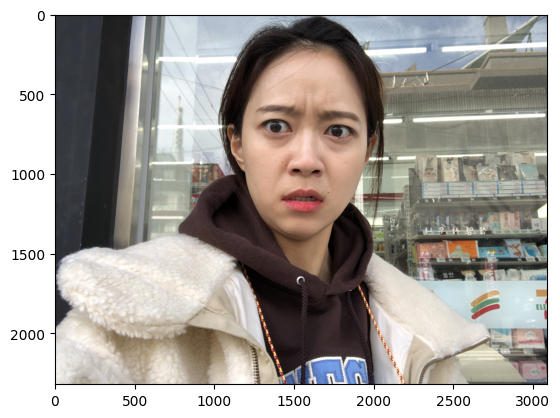

In [11]:
plt.imshow(image)

**Segmentation**

In [ ]:
# .npy : 세그멘테이션 파일, 배열 형태
# .npz : 여러개의 배열 묶음(zip)

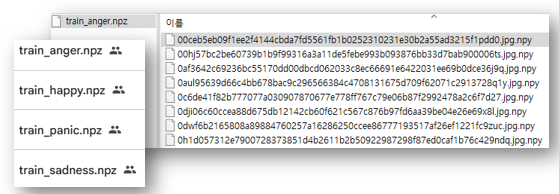

In [13]:
### npy 파일 = Segmentation 파일
   # 각 이미지의 Segmentation mask 가 ndarray 형식으로 저장
   # .jpg → .npy 변환 저장, 이미지 보다 빠른 처리 가능
   # jpg/png 파일은 별도의 디코딩 처리 후 진행, numpy 파일 포맷은 바로 사용 가능
   # ex,
     # arr = np.array([1,2,3])
     # np.save("data.npy", arr)
     # loaded = np.load("data.npy")

### npz 파일
   #  NumPy에서 제공하는 압축 파일 형식(바이너리파일)
   #  NumPy Zip
   #  ex,
      # 저장
        # np.savez("data.npz", arr1=arr1, arr2=arr2)
      # 로드
        # data = np.load("data.npz")
        # print(data["arr1"])
        # print(data["arr2"])

In [ ]:
# train_npz = np.load(TRAIN_SEGMENT_PATH + 'train_anger.npz')
train_npz = np.load("/content/train_anger.npz") # 각자 경로에 맞추세요

In [39]:
# npz : key-value 형태
        # key = 파일명
        # value = 실제 파일(픽셀별 마스크 값)

# key(파일명=배열 이름)
print(train_npz.files) # 파일명 목록


['00ceb5eb09f1ee2f4144cbda7fd5561fb1b0252310231e30b2a55ad3215f1pdd0.jpg', '00hj57bc2be60739b1b9f99316a3a11de5febe993b093876bb33d7bab900006ts.jpg', '013320f6c6aa0752eb2933111106c9bcbfaaf62b4168626b0a1f3288836bf1n3l.jpg', '03nf73f4eb25c42388b21c54304c809be3fed9c8815eb252603b90def95e3b41o.jpg', '05s25ed5288ff5e3f2172d3c4c21b368113be833decb26f3dc22e1383cc2ep3xr.jpg', '061hd8e6b7c87c0490286db2eb885f98077e37be589c89bbccbc20ee090ccv68k.jpg', '09ae5dac19f0719750d5dc8f40dedccdbd4f4a49cd77668ad955d9707e47c2ki0.jpg', '0af3642c69236bc55170dd00dbcd062033c8ec66691e6422031ee69b0dce36j9q.jpg', '0aul95639d66c4bb678bac9c296566384c4708131675d709f62071c2913728q1y.jpg', '0c6de41f82b777077a030907870677e778ff767c79e06b87f2992478a2c6f7d27.jpg', '0dji06c60ccea88d675db12142cb60f621c567c876b97fd6aa39be04e26e69x8l.jpg', '0dwf6b2165808a89884760257a16286250ccee86777193517af26ef1221fc9zuc.jpg', '0h1d057312e7900728373851d4b2611b2b50922987298f87ed0caf1b76c429ndq.jpg', '0hee6d13b154caa765569e2307f0c1b16e7fe9f072eef1ffc

In [38]:
# value = 실제 파일(픽셀별 마스크 값)

key = train_npz.files[0] # 파일명 가져오기
value = train_npz[key]   # 값 가져오기,  file_name = key

value


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [4, 4, 4, ..., 0, 0, 0],
       [4, 4, 4, ..., 0, 0, 0],
       [4, 4, 4, ..., 0, 0, 0]], dtype=uint8)

In [40]:
print(type(value)) # 파일 타입
print(value.shape) # 마스크 배열의 크기(해상도) 확인

<class 'numpy.ndarray'>
(3024, 4032)


In [30]:
file_name = "0af3642c69236bc55170dd00dbcd062033c8ec66691e6422031ee69b0dce36j9q.jpg"
# mask = train_npz[file_name]

In [32]:
# 해당 이미지의 픽셀 단위 segmentation mask 값 확인
# (2320 * 3088)개의 마스크 값

mask = train_npz[file_name]
print(mask)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [4 4 4 ... 0 0 0]
 [4 4 4 ... 0 0 0]
 [4 4 4 ... 0 0 0]]


In [17]:
colors = ['purple', 'yellow', 'red', 'green', 'blue', 'orange']
cmap = ListedColormap(colors)

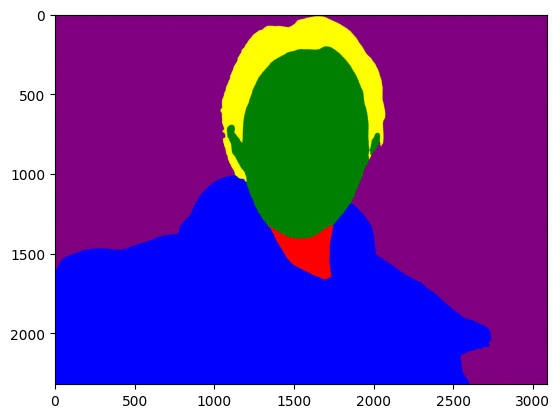

In [18]:
plt.imshow(train_npz[file_name], cmap=cmap, vmin=0, vmax=5)

보라색 0

노란색 1

빨간색 2

초록색 3

파란색 4

주황색 5

In [19]:
train_npz[file_name]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [4, 4, 4, ..., 0, 0, 0],
       [4, 4, 4, ..., 0, 0, 0],
       [4, 4, 4, ..., 0, 0, 0]], dtype=uint8)

**background masking**

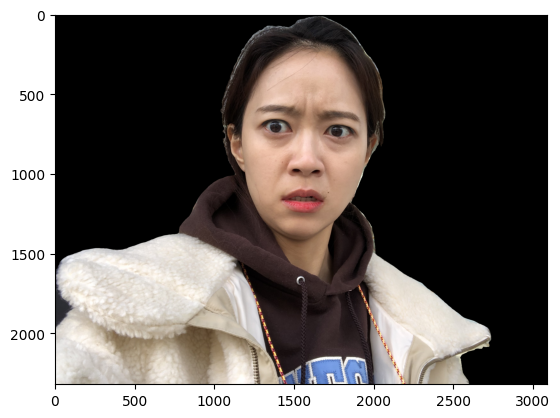

In [20]:
# 0 = background / 1 = hair / 2 = body / 3 = face / 4 = cloth / 5 = etc
new_img = image.copy()  ### 원본 이미지 copy
new_img[train_npz[file_name] == 0] = 0
   # train_npz[file_name] == 0  세그멘테이션 마스크에서 클래스 0(배경)인 픽셀 위치만 선택
   # 마스크에서 배경(0)으로 표시된 위치의 이미지 픽셀 값을 0(검정색)으로 설정

plt.imshow(new_img)

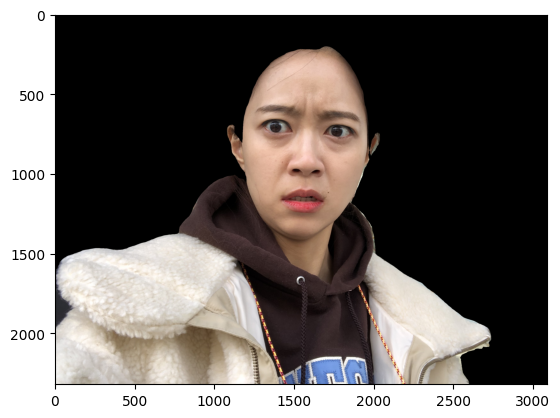

In [21]:
new_img[train_npz[file_name] == 1] = 0


plt.imshow(new_img)

**배경 면적 계산**

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [23]:
# npz 파일 로드
# segmentations = np.load('각자 경로에 맞추세요...../data/segmentation/train/train_happy.npz')

# 사용자 정의 컬러 맵 생성
colors = ['purple', 'yellow', 'red', 'green', 'blue', 'orange']
cmap = ListedColormap(colors)

In [ ]:
# train_npz.files
  # .npz 에 저장된 배열 이름 목록

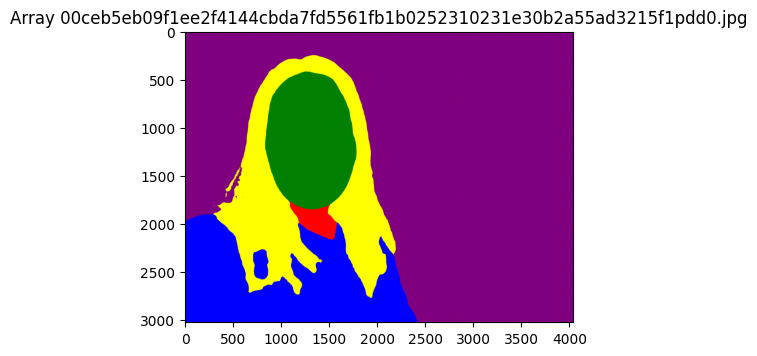

Segment area ratios for 00ceb5eb09f1ee2f4144cbda7fd5561fb1b0252310231e30b2a55ad3215f1pdd0.jpg:
background: 63.35%
hair: 13.68%
body: 0.84%
face: 8.72%
cloth: 13.41%
etc: 0.00%
Segment areas for 00ceb5eb09f1ee2f4144cbda7fd5561fb1b0252310231e30b2a55ad3215f1pdd0.jpg:
background: 7724653 pixels
hair: 1668336 pixels
body: 101961 pixels
face: 1063241 pixels
cloth: 1634577 pixels
etc: 0 pixels


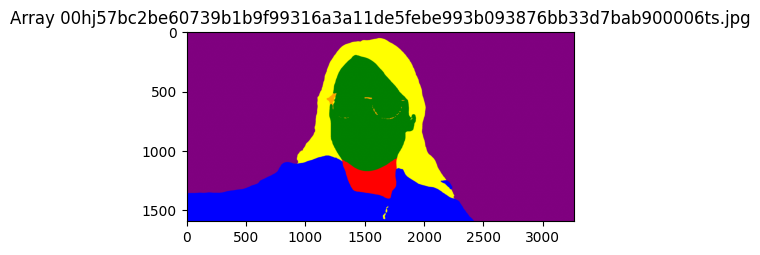

Segment area ratios for 00hj57bc2be60739b1b9f99316a3a11de5febe993b093876bb33d7bab900006ts.jpg:
background: 65.51%
hair: 8.31%
body: 1.74%
face: 9.42%
cloth: 14.90%
etc: 0.12%
Segment areas for 00hj57bc2be60739b1b9f99316a3a11de5febe993b093876bb33d7bab900006ts.jpg:
background: 3404168 pixels
hair: 432014 pixels
body: 90670 pixels
face: 489293 pixels
cloth: 774062 pixels
etc: 6081 pixels


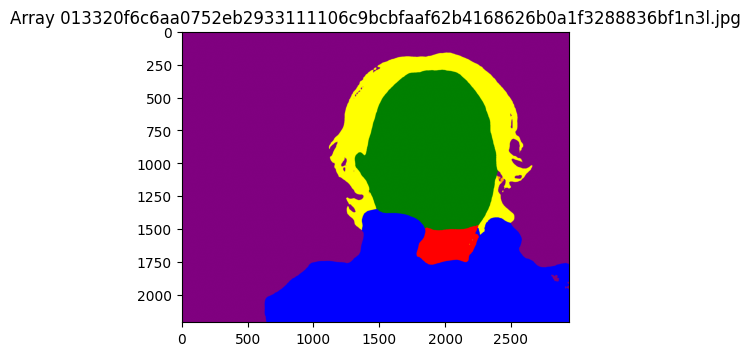

Segment area ratios for 013320f6c6aa0752eb2933111106c9bcbfaaf62b4168626b0a1f3288836bf1n3l.jpg:
background: 55.92%
hair: 7.92%
body: 1.57%
face: 15.15%
cloth: 19.42%
etc: 0.02%
Segment areas for 013320f6c6aa0752eb2933111106c9bcbfaaf62b4168626b0a1f3288836bf1n3l.jpg:
background: 3634824 pixels
hair: 514857 pixels
body: 101930 pixels
face: 985099 pixels
cloth: 1262250 pixels
etc: 1392 pixels


In [24]:
# .npz 파일에 저장된 세그멘테이션 마스크 배열 호출
# 각 배열의 클래스별 면적/비율 계산
# 이미지 시각화 (imshow)

# 첫 3개 배열의 면적 및 이미지 확인
for i, arr_name in enumerate(train_npz.files):  # enumerate() 인덱스, 이름  가져옴
    if i >= 3:  # 첫 3개 배열만 처리
        break

    # 배열 데이터 로드
    array = train_npz[arr_name]
        # .npz 파일 내 arr_name 키에 해당하는 NumPy 배열 로드

    # 각 세그먼트의 면적 계산
    segment_areas = {   # 딕셔너리로 형대로 저장 (key = 클래스 이름(color_label)y, value = 면적
        color_label: np.sum(array == index)  # array: 세그멘테이션 마스크 (numpy.ndarray) (2320, 3088)
                          # 세그멘테이션 마스크에서 특정 클래스에 해당하는 위치만 True
                          # ex, array == 0 : 클래스 0(배경)에 해당하는 픽셀만 True
                     # 불리언 배열에서 True 개수 count = 해당 클래스에 속한 픽셀 수 = 면적
        for index, color_label in enumerate(['background', 'hair', 'body', 'face', 'cloth', 'etc'])
    }
    total_area = array.size # 전체 픽셀 수 (2320 * 3088 = 7,153,600 픽셀)


    # 세그먼트 별 면적 비율 계산
    segment_ratios = {segment: area / total_area for segment, area in segment_areas.items()}

    # 이미지 출력
    plt.figure(figsize=(5, 5))
    plt.imshow(array, cmap=cmap)
    plt.title(f"Array {arr_name}")
    # plt.colorbar(ticks=range(len(colors)), label='Segmentation Classes')
    plt.clim(-0.5, len(colors) - 0.5)
    plt.show()

    # 세그먼트 별 면적 비율 출력
    print(f"Segment area ratios for {arr_name}:")
    for segment, ratio in segment_ratios.items():
        print(f"{segment}: {ratio:.2%}")

    # 세그먼트 별 면적 출력
    print(f"Segment areas for {arr_name}:")
    for segment, area in segment_areas.items():
        print(f"{segment}: {area} pixels")

# 파일 닫기
train_npz.close()

In [ ]:
# 얼굴 좌표 정보..  cropping

In [25]:
import json
import cv2
import matplotlib.pyplot as plt

# JSON 예시 데이터 (문자열이 아닌 실제 json 객체라면 이 부분 생략 가능)
data = {
    'filename': 'q347e9fe539cb67cc112ec595fa351e0ae0ab1e57027fb595c7190e1911ddkwas.jpg',
    'gender': '여',
    'age': 30,
    'isProf': '전문인',
    'faceExp_uploader': '분노',
    'bg_uploader': '공공시설/종교/의료시설',
    'annot_A': {
        'boxes': {
            'maxX': 2421.475296711904,
            'maxY': 1753.3342699198474,
            'minX': 1537.941484944897,
            'minY': 581.617503038732
        },
        'faceExp': '분노',
        'bg': '공공시설/종교/의료'
    }
}

In [27]:
# 이미지 파일 경로 설정
image_path = '/content/q347e9fe539cb67cc112ec595fa351e0ae0ab1e57027fb595c7190e1911ddkwas.jpg'

# 이미지 읽기 (OpenCV는 BGR 형식으로 읽음)
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"이미지 파일을 찾을 수 없습니다: {image_path}")


In [28]:
# 이미지 읽기 (OpenCV는 BGR 형식으로 읽음)
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"이미지 파일을 찾을 수 없습니다: {image_path}")

# BGR → RGB 변환 (matplotlib에 맞게)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [ ]:
# 박스 좌표 정보
box = data['annot_A']['boxes']
minX, minY = int(box['minX']), int(box['minY'])
maxX, maxY = int(box['maxX']), int(box['maxY'])

# bounding box 그리기
cv2.rectangle(image_rgb, (minX, minY), (maxX, maxY), color=(255, 0, 0), thickness=5)

# 텍스트 라벨 (감정 정보)
label = data['annot_A']['faceExp']
cv2.putText(image_rgb, label, (minX, minY - 10), cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 0, 0), 4)

# 시각화
plt.figure(figsize=(10, 10))
plt.imshow(image_rgb)
plt.axis('off')
plt.title(f"emotion: {label}")
plt.show()
